In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ── Cell 2: Imports ──────────────────────────────────────────────
import os, cv2, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                      GlobalMaxPooling2D, Dropout,
                                      BatchNormalization, Concatenate, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (ReduceLROnPlateau, EarlyStopping,
                                         ModelCheckpoint, Callback)
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Cell 3: Dataset loading ───────────────────────────────────────
IMG_SIZE = 224   # EfficientNetB0 native input size

def load_dataset(base_path):
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    for label, cls in enumerate(class_names):
        cls_folder = os.path.join(base_path, cls)
        count = 0
        for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif img.shape[2] == 1:
                img = np.concatenate([img]*3, axis=2)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE),
                             interpolation=cv2.INTER_LANCZOS4)
            X.append(img)
            y.append(label)
            count += 1
        print(f"  {cls}: {count} images")

    # Keep as uint8 — EfficientNetB0 will normalise internally
    return np.array(X, dtype=np.uint8), np.array(y), class_names

In [ ]:
# ── Cell 4: Load data ─────────────────────────────────────────────
dataset_path = "/content/drive/MyDrive/brain-tumor-classification/data/processed/Training"

X, y, class_names = load_dataset(dataset_path)
num_classes = len(class_names)

print(f"\nTotal images : {len(X)}")
print(f"Image shape  : {X[0].shape}")
print(f"Classes      : {class_names}")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(class_names, counts):
    print(f"  {cls}: {cnt}")

  glioma_tumor: 826 images
  meningioma_tumor: 822 images
  no_tumor: 395 images
  pituitary_tumor: 827 images

Total images : 2870
Image shape  : (224, 224, 3)
Classes      : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor: 826
  meningioma_tumor: 822
  no_tumor: 395
  pituitary_tumor: 827


In [ ]:
# ── Cell 5: Train / Val / Test split ─────────────────────────────
X_tr_full, X_test, y_tr_full, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.111, random_state=42,
    stratify=y_tr_full)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print(f"Train : {len(X_train)}  Val : {len(X_val)}  Test : {len(X_test)}")

Train : 2296  Val : 287  Test : 287


In [ ]:
# ── Cell 6: Class weights ─────────────────────────────────────────
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights:")
for cls, w in zip(class_names, class_weights_arr):
    print(f"  {cls}: {w:.4f}")

Class weights:
  glioma_tumor: 0.8697
  meningioma_tumor: 0.8723
  no_tumor: 1.8107
  pituitary_tumor: 0.8684


In [ ]:
# ── Cell 7: Data Augmentation ─────────────────────────────────────


train_datagen = ImageDataGenerator(
    # rescale=1./255   ← REMOVED (was double-rescaling EfficientNet)
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    shear_range=0.08,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.85, 1.15],
    fill_mode='reflect'
)

# Val / test: NO rescale (EfficientNet handles it)
val_datagen  = ImageDataGenerator()
test_datagen = ImageDataGenerator()

batch_size = 32
train_gen = train_datagen.flow(X_train, y_train_cat,
                                batch_size=batch_size, shuffle=True)
val_gen   = val_datagen.flow(X_val,   y_val_cat,
                              batch_size=batch_size, shuffle=False)
test_gen  = test_datagen.flow(X_test,  y_test_cat,
                               batch_size=batch_size, shuffle=False)

steps_per_epoch  = len(X_train) // batch_size
validation_steps = len(X_val)   // batch_size

print(f"Generators ready — {steps_per_epoch} steps/epoch")

Generators ready — 71 steps/epoch


In [ ]:
# ── Cell 8: Model architecture ────────────────────────────────────
def build_model(num_classes, input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # weights='imagenet' → built-in preprocessing included
    # include_top=False  → we add our own head
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )
    base.trainable = False   # Phase 1: freeze backbone

    # Dual-pool head  (avg + max → richer features)
    avg = GlobalAveragePooling2D()(base.output)
    mx  = GlobalMaxPooling2D()(base.output)
    x   = Concatenate()([avg, mx])        # (batch, 2560)

    x = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    out = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, out), base

model, base_model = build_model(num_classes)
print(f"Total params: {model.count_params():,}")
print(f"Trainable params (Phase-1): "
      f"{sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

Total params: 5,496,231
Trainable params (Phase-1): 1,445,124


In [ ]:
# ── Cell 9: Callbacks ─────────────────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/brain-tumor-classification/models"
os.makedirs(SAVE_DIR, exist_ok=True)
ckpt_path = os.path.join(SAVE_DIR, "effnet_best.keras")

def make_callbacks(patience_lr=5, patience_es=15):
    return [
        ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                          patience=patience_lr, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=patience_es,
                      restore_best_weights=True, verbose=1),
    ]

print("Callbacks ready.")

Callbacks ready.


In [ ]:
# ── Cell 10: Phase 1 — train head only ───────────────────────────
print("="*55)
print("PHASE 1 — frozen backbone, training head only")
print("="*55)

model.compile(
    optimizer=Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

hist1 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=val_gen,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(patience_lr=5, patience_es=12),
    verbose=1
)

p1_best = max(hist1.history['val_accuracy'])
print(f"\nPhase-1 best val accuracy: {p1_best*100:.2f}%")

PHASE 1 — frozen backbone, training head only
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.6028 - loss: 1.3370
Epoch 1: val_accuracy improved from None to 0.61328, saving model to /content/drive/MyDrive/brain-tumor-classification/models/effnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/effnet_best.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 83s 779ms/step - accuracy: 0.6572 - loss: 1.1656 - val_accuracy: 0.6133 - val_loss: 1.4104 - learning_rate: 0.0010
Epoch 2/30
 1/71 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8438 - loss: 0.7882
Epoch 2: val_accuracy improved from 0.61328 to 0.63281, saving model to /content/drive/MyDrive/brain-tumor-classification/models/effnet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/effnet_best.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8438 - loss: 0.7882 - val_accuracy: 0.6328 - val_loss: 1.3148 - learning_rat

In [ ]:
# ── Cell 11: Phase 2 — fine-tune top layers ───────────────────────
print("="*55)
print("PHASE 2 — fine-tuning top 50 backbone layers")
print("="*55)

base_model.trainable = True
fine_tune_from = len(base_model.layers) - 50

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# Keep ALL BatchNorm frozen — preserves ImageNet statistics
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable backbone layers: {trainable} / {len(base_model.layers)}")

model.compile(
    optimizer=Adam(1e-5),   # very low LR — don't destroy pre-trained weights
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

hist2 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=40,
    validation_data=val_gen,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(patience_lr=6, patience_es=18),
    verbose=1
)

p2_best = max(hist2.history['val_accuracy'])
print(f"\nPhase-2 best val accuracy: {p2_best*100:.2f}%")

PHASE 2 — fine-tuning top 50 backbone layers
Trainable backbone layers: 39 / 238
Epoch 1/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9203 - loss: 0.5157
Epoch 1: val_accuracy improved from None to 0.91016, saving model to /content/drive/MyDrive/brain-tumor-classification/models/effnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/effnet_best.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9218 - loss: 0.5042 - val_accuracy: 0.9102 - val_loss: 0.5031 - learning_rate: 1.0000e-05
Epoch 2/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9375 - loss: 0.4835
Epoch 2: val_accuracy did not improve from 0.91016
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9375 - loss: 0.4835 - val_accuracy: 0.9102 - val_loss: 0.5029 - learning_rate: 1.0000e-05
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9335 - loss: 0.4838
Epoch 3: val_accuracy did not improve from 0.91016
71/71 ━━━━━━━━━━━━━━━━

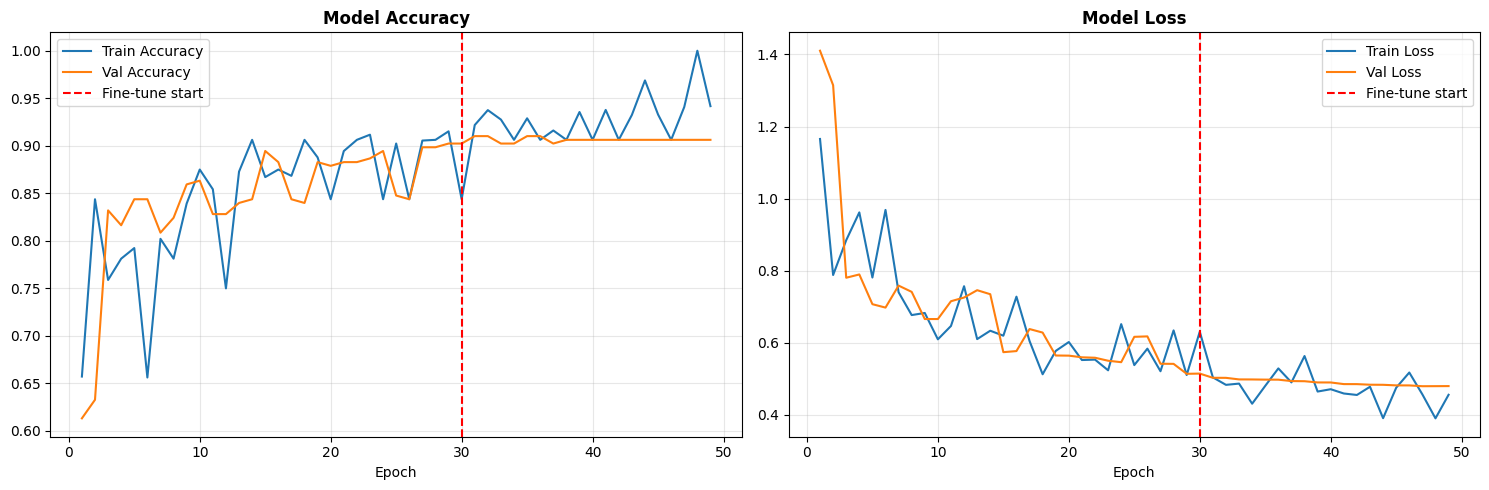

Best val accuracy: 91.02% at epoch 31


In [ ]:
# ── Cell 12: Training curves ──────────────────────────────────────
history = {k: hist1.history[k] + hist2.history[k]
           for k in hist1.history}
p1_len = len(hist1.history['accuracy'])
ep = range(1, len(history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in zip(
        axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(ep, history[metric],     label=f'Train {title}')
    ax.plot(ep, history[f'val_{metric}'], label=f'Val {title}')
    ax.axvline(p1_len, color='red', ls='--', label='Fine-tune start')
    ax.set_title(f'Model {title}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_val = max(history['val_accuracy'])
best_ep  = history['val_accuracy'].index(best_val) + 1
print(f"Best val accuracy: {best_val*100:.2f}% at epoch {best_ep}")

In [ ]:
# ── Cell 13: Load best model & evaluate ───────────────────────────
from tensorflow.keras.models import load_model

best_model = load_model(ckpt_path)

test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"\nTest loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc*100:.2f}%")

if test_acc >= 0.80:
    print("✓ Target achieved — accuracy > 80%")
else:
    print(f"⚠ {test_acc*100:.2f}% — consider more epochs")

9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 611ms/step - accuracy: 0.9059 - loss: 0.5483

Test loss     : 0.5483
Test accuracy : 90.59%
✓ Target achieved — accuracy > 80%


In [ ]:
# ── Cell 14: Predictions & metrics ───────────────────────────────
# Feed raw uint8 images — EfficientNet normalises internally
y_prob = best_model.predict(X_test, batch_size=batch_size, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test

oa  = accuracy_score(y_true, y_pred)
wp  = precision_score(y_true, y_pred, average='weighted')
wr  = recall_score(y_true, y_pred, average='weighted')
wf1 = f1_score(y_true, y_pred, average='weighted')
mp  = precision_score(y_true, y_pred, average='macro')
mr  = recall_score(y_true, y_pred, average='macro')
mf1 = f1_score(y_true, y_pred, average='macro')

print(f"\nOverall Accuracy  : {oa*100:.2f}%")
print(f"Weighted Precision: {wp:.4f}")
print(f"Weighted Recall   : {wr:.4f}")
print(f"Weighted F1       : {wf1:.4f}")
print(f"Macro Precision   : {mp:.4f}")
print(f"Macro Recall      : {mr:.4f}")
print(f"Macro F1          : {mf1:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step

Overall Accuracy  : 90.59%
Weighted Precision: 0.9074
Weighted Recall   : 0.9059
Weighted F1       : 0.9058
Macro Precision   : 0.9066
Macro Recall      : 0.9115
Macro F1          : 0.9082


In [ ]:
# ── Cell 15: Classification report ───────────────────────────────
report = classification_report(y_true, y_pred,
                                target_names=class_names, digits=4)
print(report)

rpt_path = os.path.join(SAVE_DIR, "effnet_report.txt")
with open(rpt_path, 'w') as f:
    f.write(report)
print(f"Saved: {rpt_path}")

                  precision    recall  f1-score   support

    glioma_tumor     0.9467    0.8554    0.8987        83
meningioma_tumor     0.8353    0.8659    0.8503        82
        no_tumor     0.9024    0.9487    0.9250        39
 pituitary_tumor     0.9419    0.9759    0.9586        83

        accuracy                         0.9059       287
       macro avg     0.9066    0.9115    0.9082       287
    weighted avg     0.9074    0.9059    0.9058       287

Saved: /content/drive/MyDrive/brain-tumor-classification/models/effnet_report.txt


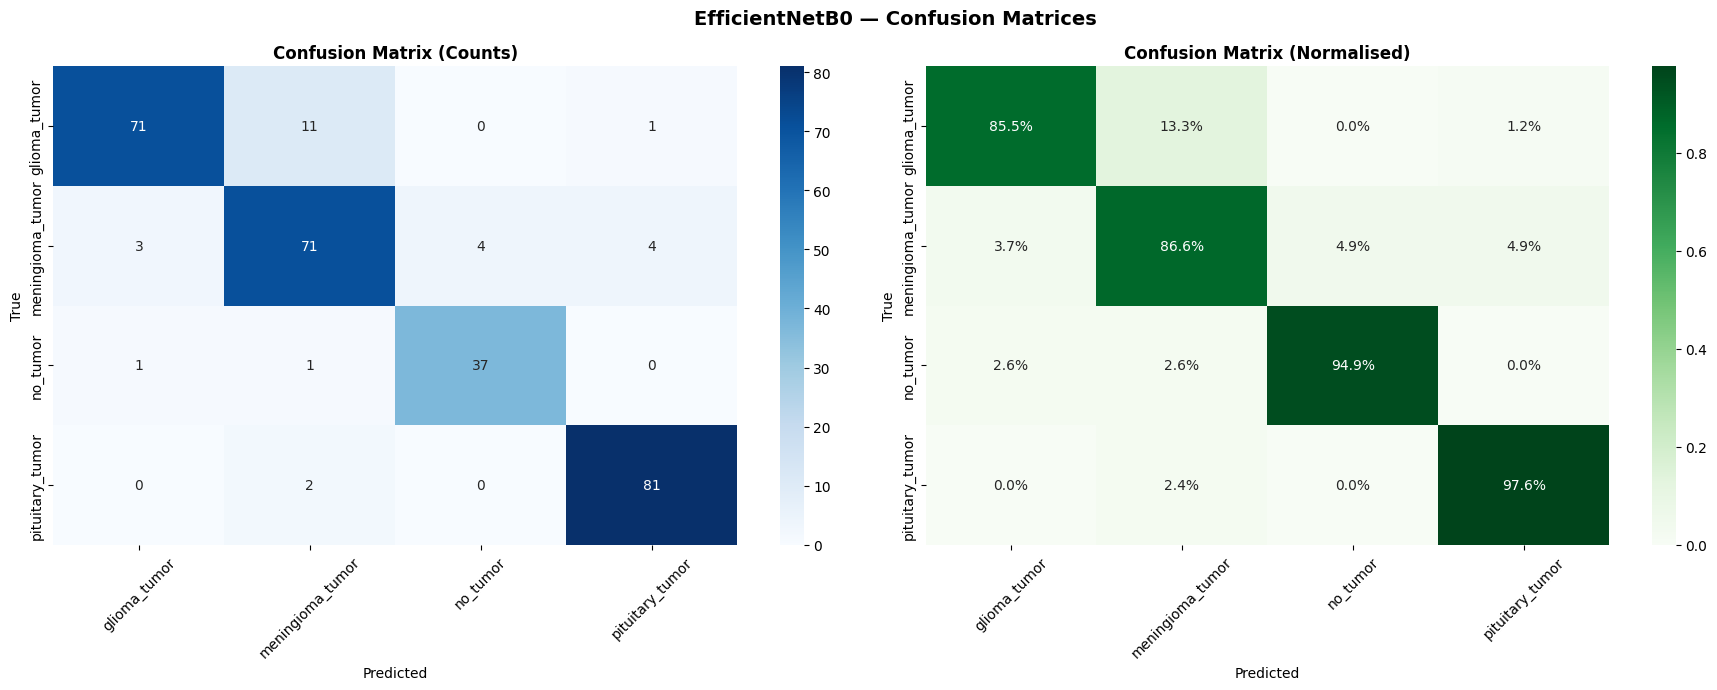

In [ ]:
# ── Cell 16: Confusion matrices ───────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('EfficientNetB0 — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

glioma_tumor          acc=85.54%  prec=94.67%  rec=85.54%  f1=89.87%  [71/83]
meningioma_tumor      acc=86.59%  prec=83.53%  rec=86.59%  f1=85.03%  [71/82]
no_tumor              acc=94.87%  prec=90.24%  rec=94.87%  f1=92.50%  [37/39]
pituitary_tumor       acc=97.59%  prec=94.19%  rec=97.59%  f1=95.86%  [81/83]


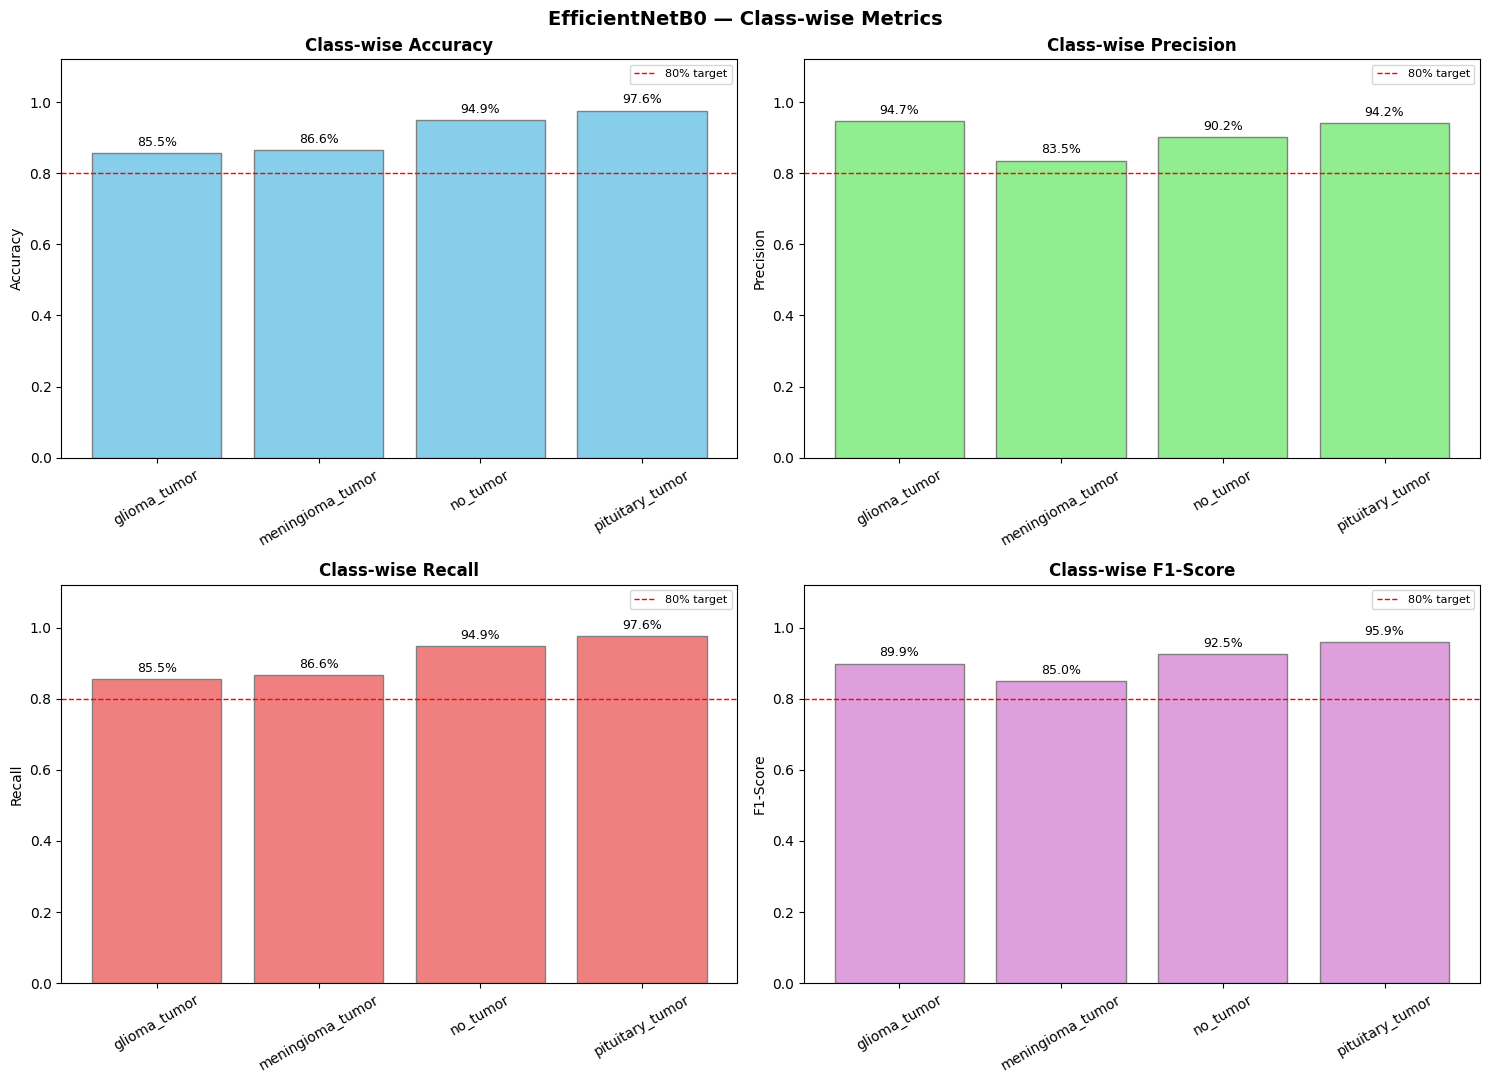

In [ ]:
# ── Cell 17: Class-wise bar charts ────────────────────────────────
c_acc, c_prec, c_rec, c_f1 = [], [], [], []

for i in range(num_classes):
    idx = np.where(y_true == i)[0]
    preds = y_pred[idx]
    tp = np.sum(preds == i)
    fp = np.sum(y_pred == i) - tp
    fn = len(idx) - tp
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec  = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1v  = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    c_acc.append(tp/len(idx))
    c_prec.append(prec)
    c_rec.append(rec)
    c_f1.append(f1v)

    print(f"{class_names[i]:20s}  acc={tp/len(idx):.2%}  "
          f"prec={prec:.2%}  rec={rec:.2%}  f1={f1v:.2%}  [{tp}/{len(idx)}]")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
spec = [('Accuracy','skyblue',c_acc), ('Precision','lightgreen',c_prec),
        ('Recall','lightcoral',c_rec), ('F1-Score','plum',c_f1)]

for ax, (title, color, vals) in zip(axes.ravel(), spec):
    bars = ax.bar(class_names, vals, color=color, edgecolor='grey')
    ax.set_ylim(0, 1.12)
    ax.set_title(f'Class-wise {title}', fontweight='bold')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(0.80, color='red', ls='--', lw=1, label='80% target')
    ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02,
                f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle('EfficientNetB0 — Class-wise Metrics', fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.show()

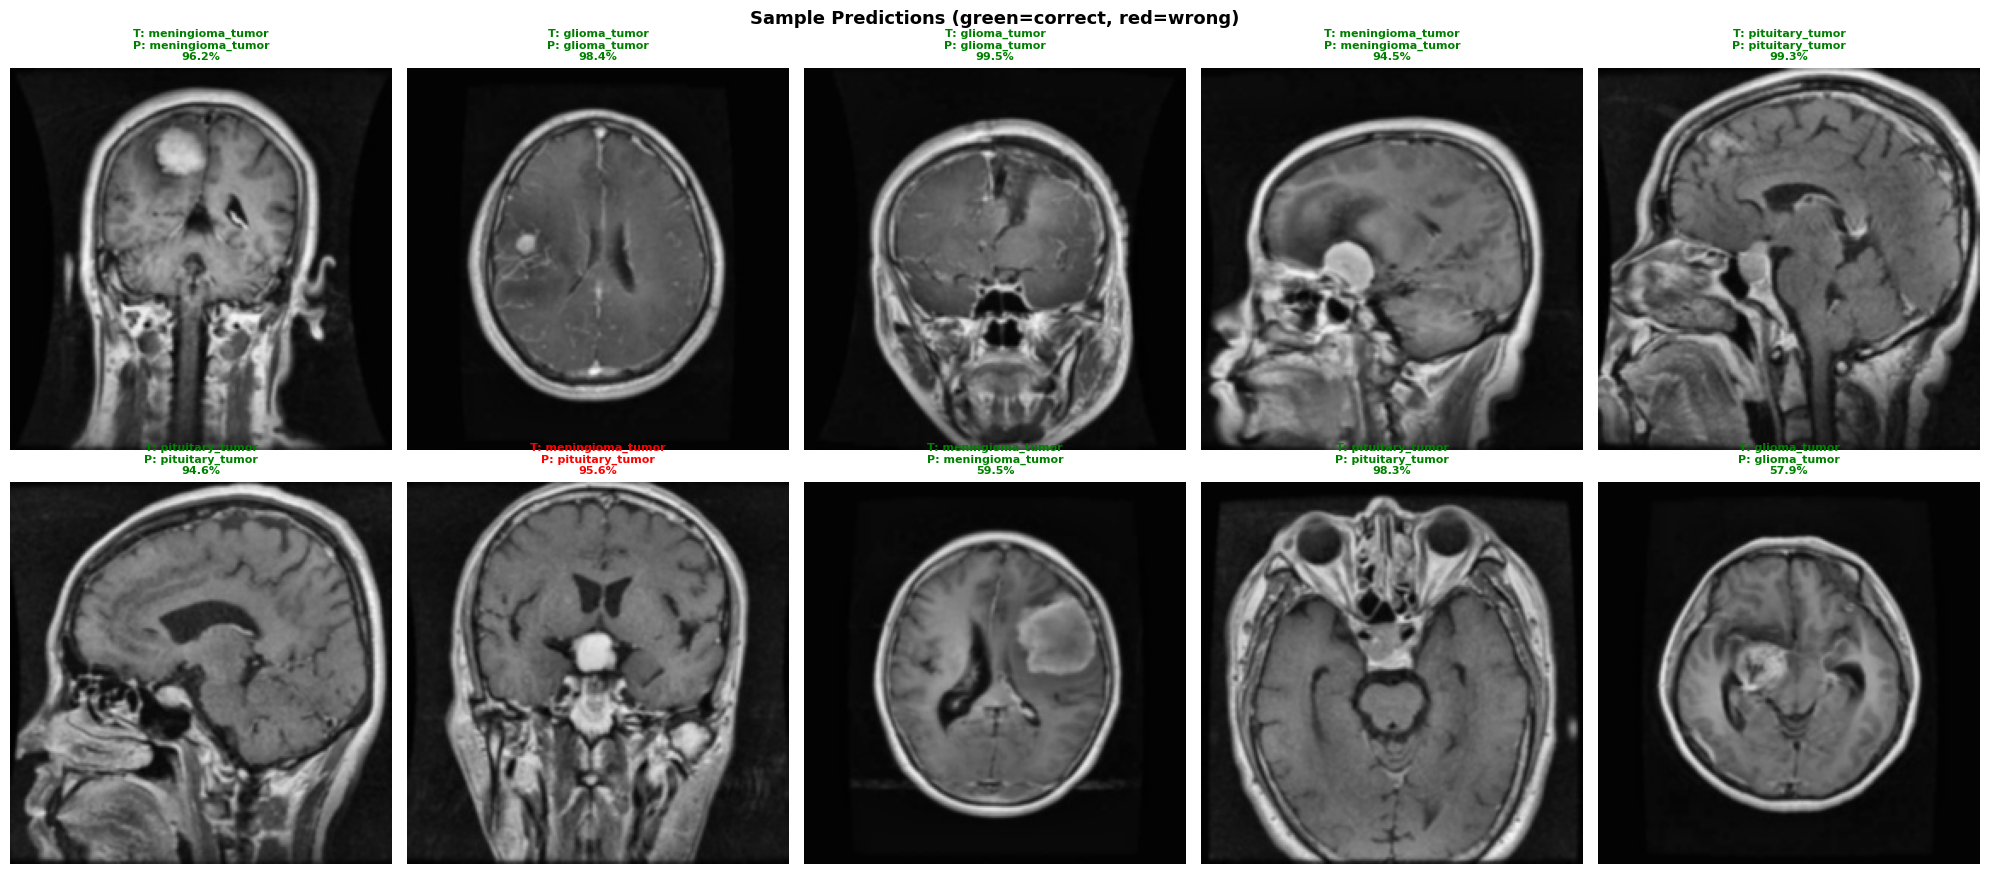

In [ ]:
# ── Cell 18: Prediction on random test images ─────────────────────
def predict_one(model, img_uint8, class_names):
    """img_uint8: (224,224,3) uint8 — no manual rescaling needed."""
    x = np.expand_dims(img_uint8.astype(np.float32), 0)
    probs = model.predict(x, verbose=0)[0]
    idx   = np.argmax(probs)
    return class_names[idx], probs[idx], probs

idxs = np.random.choice(len(X_test), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(20, 9))

for ax, i in zip(axes.ravel(), idxs):
    img = X_test[i]
    true_lbl = class_names[y_test[i]]
    pred_lbl, conf, _ = predict_one(best_model, img, class_names)
    ax.imshow(img)
    ax.axis('off')
    color = 'green' if pred_lbl == true_lbl else 'red'
    ax.set_title(f'T: {true_lbl}\nP: {pred_lbl}\n{conf:.1%}',
                 fontsize=8, color=color, fontweight='bold')

plt.suptitle('Sample Predictions (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 19: Save model & artefacts ──────────────────────────────
save_dir = os.path.join(SAVE_DIR, "EfficientNetB0_V3")
os.makedirs(save_dir, exist_ok=True)

best_model.save(os.path.join(save_dir, "model.keras"))
best_model.save(os.path.join(save_dir, "model.h5"))

with open(os.path.join(save_dir, 'class_names.pkl'), 'wb') as f:
    pickle.dump(class_names, f)

with open(os.path.join(save_dir, 'history.pkl'), 'wb') as f:
    pickle.dump(history, f)

metrics_txt = (
    f"Overall Accuracy   : {oa*100:.2f}%\n"
    f"Weighted Precision : {wp:.4f}\n"
    f"Weighted Recall    : {wr:.4f}\n"
    f"Weighted F1        : {wf1:.4f}\n"
    f"Macro F1           : {mf1:.4f}\n\n"
    + report
)
with open(os.path.join(save_dir, 'metrics.txt'), 'w') as f:
    f.write(metrics_txt)

print(f"All files saved to: {save_dir}")

All files saved to: /content/drive/MyDrive/brain-tumor-classification/models/EfficientNetB0_V3


In [ ]:
# ── Cell 20: Final summary ────────────────────────────────────────
print("\n" + "="*65)
print("FINAL SUMMARY — EfficientNetB0 Brain Tumour Classifier V3")
print("="*65)
print(f"Classes  : {', '.join(class_names)}")
print(f"Dataset  : {len(X)} images  "
      f"(train {len(X_train)} / val {len(X_val)} / test {len(X_test)})")
print(f"Accuracy : {test_acc*100:.2f}%")
print(f"Macro F1 : {mf1:.4f}")
print()
print("Root-cause fix applied:")
print("  rescale=1./255 removed from ALL generators.")
print("  EfficientNetB0 normalises inputs internally (0-255 → [-1,1]).")
print("  Double-rescaling previously sent inputs to ~0 → random guessing.")
print("="*65)


FINAL SUMMARY — EfficientNetB0 Brain Tumour Classifier V3
Classes  : glioma_tumor, meningioma_tumor, no_tumor, pituitary_tumor
Dataset  : 2870 images  (train 2296 / val 287 / test 287)
Accuracy : 90.59%
Macro F1 : 0.9082

Root-cause fix applied:
  rescale=1./255 removed from ALL generators.
  EfficientNetB0 normalises inputs internally (0-255 → [-1,1]).
  Double-rescaling previously sent inputs to ~0 → random guessing.
